# Outlier Patch Detection on TR1 Data

Applies the per-patch amplitude perturbation analysis from `outlier_patch_test.ipynb`
to the first TR1 shear map (`SHE-1`).  The 48-patch tile mask serves as both the
patch decomposition and the jackknife regions.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

import heracles
import heracles.healpy
import heracles.dices as dices

## 1. Load catalog and build shear maps

We read `23405.fits` with `heracles.FitsCatalog` and select tomographic bin 1.
The shear (SHE) and weight (WHT) maps are produced by `heracles.map_catalogs`
using the LensMC ellipticity columns (`she_lensmc_e1/e2/weight`).

In [ ]:
from heracles.core import update_metadata

DATA_DIR  = "tr1_data"
CAT_FILE  = f"{DATA_DIR}/23405.fits"

nside     = 1024
lmax_data = 2000
lmax_mask = 3000
lmax_out  = 1500
lmin      = 300
nlbins    = 10
methods   = ["metacal", "lensmc"]  # both shear estimators

mask = hp.read_map("/home/jaimerzp/Documents/software/heracles/examples/tr1_data/tr1_mask.fits")

catalog  = heracles.FitsCatalog(CAT_FILE)
catalog.visibility = mask
catalogs = {0: catalog}
for i in range(1, 7):
    catalogs[i] = catalog[catalog["tom_bin_id"] == i]

mapper_data = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_data)
mapper_mask = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_mask)

she_maps_all = {}
wht_maps_all = {}

for method in methods:
    fields_map = {
        "SHE": heracles.Shears(
            mapper_data,
            "right_ascension",
            "declination",
            f"she_{method}_e1",
            f"-she_{method}_e2",
            f"she_{method}_weight",
            mask="WHT",
        ),
    }
    fields_mask_def = {
        "WHT": heracles.Weights(
            mapper_mask,
            "right_ascension",
            "declination",
            f"she_{method}_weight",
        ),
    }
    she_maps_all[method] = heracles.map_catalogs(fields_map, catalogs)
    wht_maps_all[method] = heracles.map_catalogs(fields_mask_def, catalogs)
    print(f"  Mapped {method}")


  Mapped metacal
  Mapped lensmc


## 2. Build the patch segmentation map

We divide the survey footprint into roughly 20-sq-deg patches using
`skysegmentor.segmentmapN` on the WHT weight map.

In [3]:
import skysegmentor

# Per-method bias from metadata
b_all = {
    method: she_maps_all[method][("SHE", 1)].dtype.metadata["bias"]
    for method in methods
}

# Target ~20 sq deg per patch (patch layout is method-independent)
fsky      = mask.sum() / hp.nside2npix(nside)
area_deg2 = fsky * 4 * np.pi * (180 / np.pi) ** 2
n_patches = max(1, round(area_deg2 / 20))
print(f"Survey area: {area_deg2:.1f} sq deg  →  {n_patches} patches of ~{area_deg2/n_patches:.1f} sq deg each")

jkmap = skysegmentor.segmentmapN(mask, n_patches)
print(f"jkmap unique labels: {np.unique(jkmap[jkmap > 0]).astype(int)}")


Survey area: 504.5 sq deg  →  25 patches of ~20.2 sq deg each
jkmap unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]


/tmp/ipykernel_24653/3289705106.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon_c, lat_c = float(lon_c), float(lat_c)
/tmp/ipykernel_24653/3289705106.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


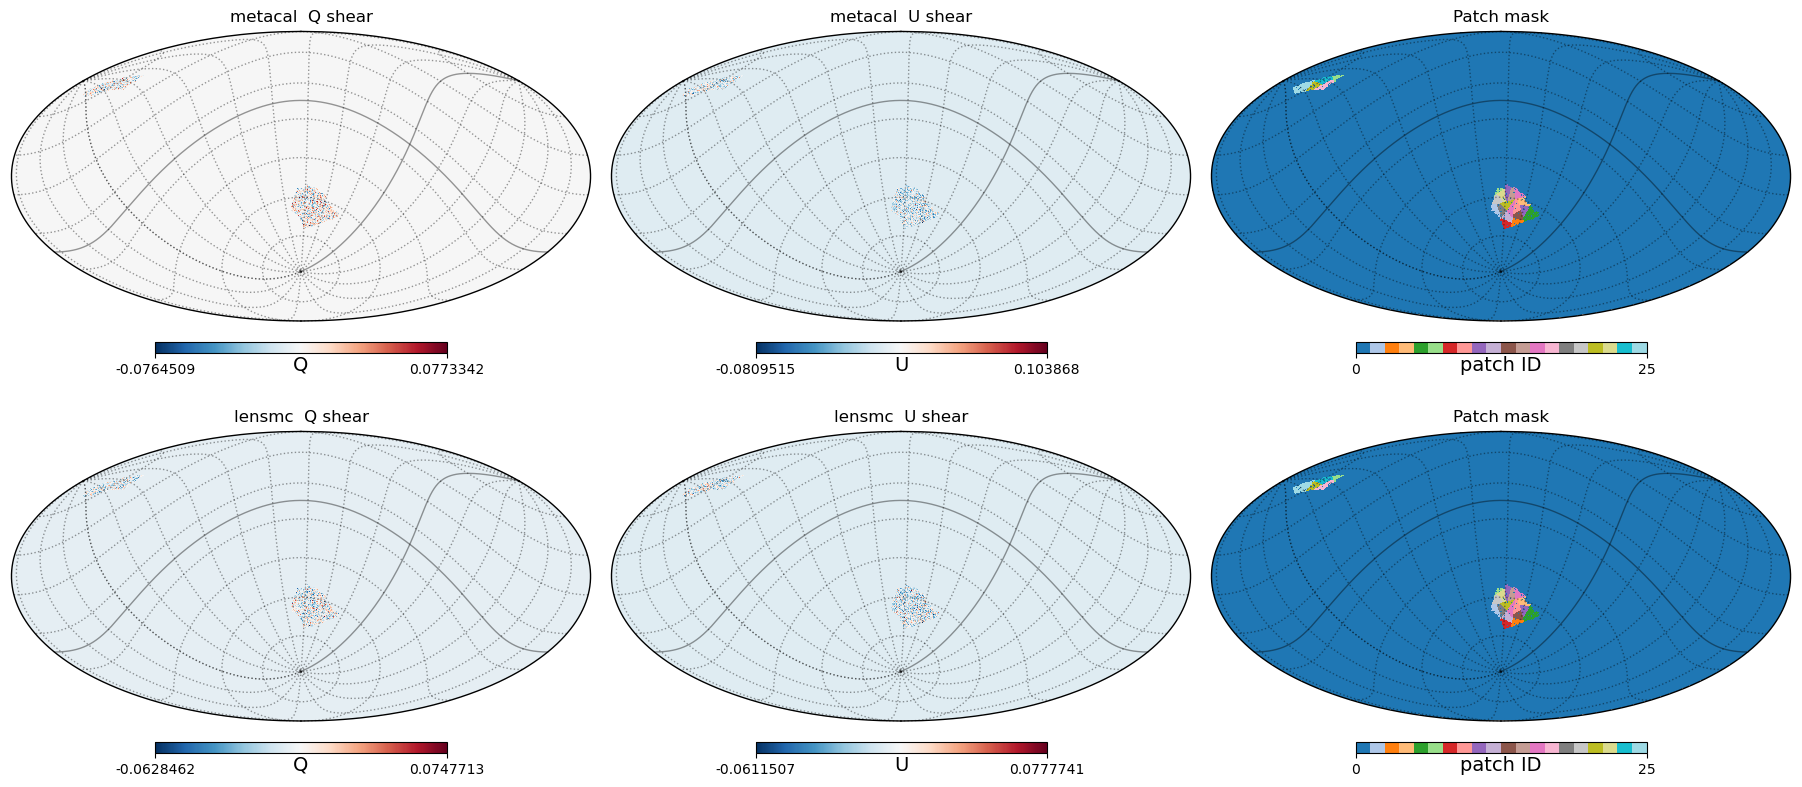

In [4]:
# ── Diagnostic: SHE-1 maps for both methods + patch regions ──
footprint_pix = np.where(she_maps_all["lensmc"][("SHE", 1)][0] != 0)[0]
vec = np.array(hp.pix2vec(nside, footprint_pix))
centre_vec = vec.mean(axis=1)
centre_vec /= np.linalg.norm(centre_vec)
lon_c, lat_c = hp.vec2ang(centre_vec, lonlat=True)
lon_c, lat_c = float(lon_c), float(lat_c)

fig = plt.figure(figsize=(18, 8))

for row, method in enumerate(methods):
    she_m = she_maps_all[method]
    hp.mollview(
        she_m[("SHE", 1)][0], fig=fig, sub=(2, 3, row * 3 + 1),
        rot=(lon_c, lat_c, 0),
        title=f"{method}  Q shear", unit="Q",
        cmap="RdBu_r", notext=True,
    )
    hp.mollview(
        she_m[("SHE", 1)][1], fig=fig, sub=(2, 3, row * 3 + 2),
        rot=(lon_c, lat_c, 0),
        title=f"{method}  U shear", unit="U",
        cmap="RdBu_r", notext=True,
    )
    hp.mollview(
        jkmap, fig=fig, sub=(2, 3, row * 3 + 3),
        rot=(lon_c, lat_c, 0),
        title="Patch mask", unit="patch ID",
        cmap="tab20", notext=True,
    )

hp.graticule(dpar=5, dmer=5, alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Heracles setup

In [5]:
# Per-patch and full-footprint naturalspice: SHE @ lmax_data, WHT @ lmax_mask
fields = {
    "SHE": heracles.Shears(mapper_data, mask="WHT"),
    "WHT": heracles.Weights(mapper_data),
}
print(f"Data mapper: nside={mapper_data.nside}, lmax={mapper_data.lmax}")
print(f"Mask mapper: nside={mapper_mask.nside}, lmax={mapper_mask.lmax}")

Data mapper: nside=1024, lmax=2000
Mask mapper: nside=1024, lmax=3000


## 4. Per-patch alms and pseudo-$C_\ell$

For each patch we:
1. Mask the shear and weight maps to that patch's pixels
2. Transform to alms
3. Compute the pseudo-$C_\ell$

In [6]:
import heracles.dices as dices

all_data_cls   = {method: {} for method in methods}
all_mask_cls   = {method: {} for method in methods}

for method in methods:
    she = she_maps_all[method][("SHE", 1)]
    wht = wht_maps_all[method][("WHT", 1)]
    b   = b_all[method]

    data_cls  = all_data_cls[method]
    mask_cls  = all_mask_cls[method]

    for label in range(1, n_patches + 1):
        patch_mask = jkmap == label

        she_p = she.copy(); she_p[:, ~patch_mask] = 0.0
        wht_p = wht.copy(); wht_p[~patch_mask]    = 0.0

        update_metadata(she_p, fsky=fsky/n_patches, bias=b/n_patches)

        shear_alm = mapper_data.transform(she_p)
        mask_alm  = mapper_mask.transform(wht_p)

        data_cls.update(heracles.angular_power_spectra({("SHE", label): shear_alm}))
        mask_cls.update(heracles.angular_power_spectra({("WHT", label): mask_alm}))

        if label % 5 == 0 or label == n_patches:
            print(f"  [{method}] patch {label}/{n_patches}", end=", ", flush=True)
    print(f"done.")


  [metacal] patch 5/25,   [metacal] patch 10/25,   [metacal] patch 15/25,   [metacal] patch 20/25,   [metacal] patch 25/25, done.
  [lensmc] patch 5/25,   [lensmc] patch 10/25,   [lensmc] patch 15/25,   [lensmc] patch 20/25,   [lensmc] patch 25/25, done.


## 5. Unmix the Cls of each region

`naturalspice` divides the data correlation function by the mask correlation
function in real space, correcting for mode-mixing without an explicit
mixing-matrix inversion.

In [7]:
ledges = np.logspace(np.log10(lmin), np.log10(lmax_out), nlbins + 1)

In [8]:
print("Applying naturalspice to each method/patch...")
rcond = 0.7

all_unmixed_cls    = {}
all_unmixed_binned = {}

for method in methods:
    unmixed = heracles.naturalspice(all_data_cls[method], all_mask_cls[method], fields, rcond=rcond)
    all_unmixed_cls[method]    = unmixed
    all_unmixed_binned[method] = heracles.binned(unmixed, ledges)
    print(f"  {method}: done.")


Applying naturalspice to each method/patch...
  metacal: done.
  lensmc: done.


## 6. Full-footprint $C_\ell$ and sample covariance

The full-footprint alm is the sum of per-patch alms (SHT linearity — no extra SHTs).
The covariance is the **sample covariance** of the per-region unmixed Cls,
characterising region-to-region scatter.

In [9]:
KEY = ("SHE", "SHE", "full", "full")

all_full_unmixed_b = {}
all_cl_full        = {}

for method in methods:
    she_full = she_maps_all[method][("SHE", 1)]
    wht_full = wht_maps_all[method][("WHT", 1)]

    alm_full_shear = mapper_data.transform(she_full)
    alm_full_mask  = mapper_mask.transform(wht_full)

    full_data_cls = heracles.angular_power_spectra({("SHE", "full"): alm_full_shear})
    full_mask_cls = heracles.angular_power_spectra({("WHT", "full"): alm_full_mask})

    print(f"Applying naturalspice to full footprint [{method}]...")
    full_unmixed   = heracles.naturalspice(full_data_cls, full_mask_cls, fields, rcond=rcond)
    full_unmixed_b = heracles.binned(full_unmixed, ledges)
    all_full_unmixed_b[method] = full_unmixed_b

    ell_full = full_unmixed_b[KEY].ell

    cls_patches_ee = np.array([
        np.array(all_unmixed_binned[method][("SHE", "SHE", label, label)][0, 0])
        for label in range(1, n_patches + 1)
    ])
    cls_patches_bb = np.array([
        np.array(all_unmixed_binned[method][("SHE", "SHE", label, label)][1, 1])
        for label in range(1, n_patches + 1)
    ])

    cov_ee = np.cov(cls_patches_ee.T)
    cov_bb = np.cov(cls_patches_bb.T)
    err_ee = np.sqrt(np.diag(cov_ee) / n_patches)
    err_bb = np.sqrt(np.diag(cov_bb) / n_patches)

    all_cl_full[method] = {
        "ee":             np.array(full_unmixed_b[KEY][0, 0]),
        "bb":             np.array(full_unmixed_b[KEY][1, 1]),
        "err_ee":         err_ee,
        "err_bb":         err_bb,
        "cls_patches_ee": cls_patches_ee,
        "cls_patches_bb": cls_patches_bb,
    }
    print(f"  Covariance rank: {np.linalg.matrix_rank(cov_ee)}  (nlbins={len(ell_full)}, n_patches={n_patches})")

nlbins = len(ell_full)


Applying naturalspice to full footprint [metacal]...
  Covariance rank: 10  (nlbins=10, n_patches=25)
Applying naturalspice to full footprint [lensmc]...
  Covariance rank: 10  (nlbins=10, n_patches=25)


## 6. Per-patch Cls plot

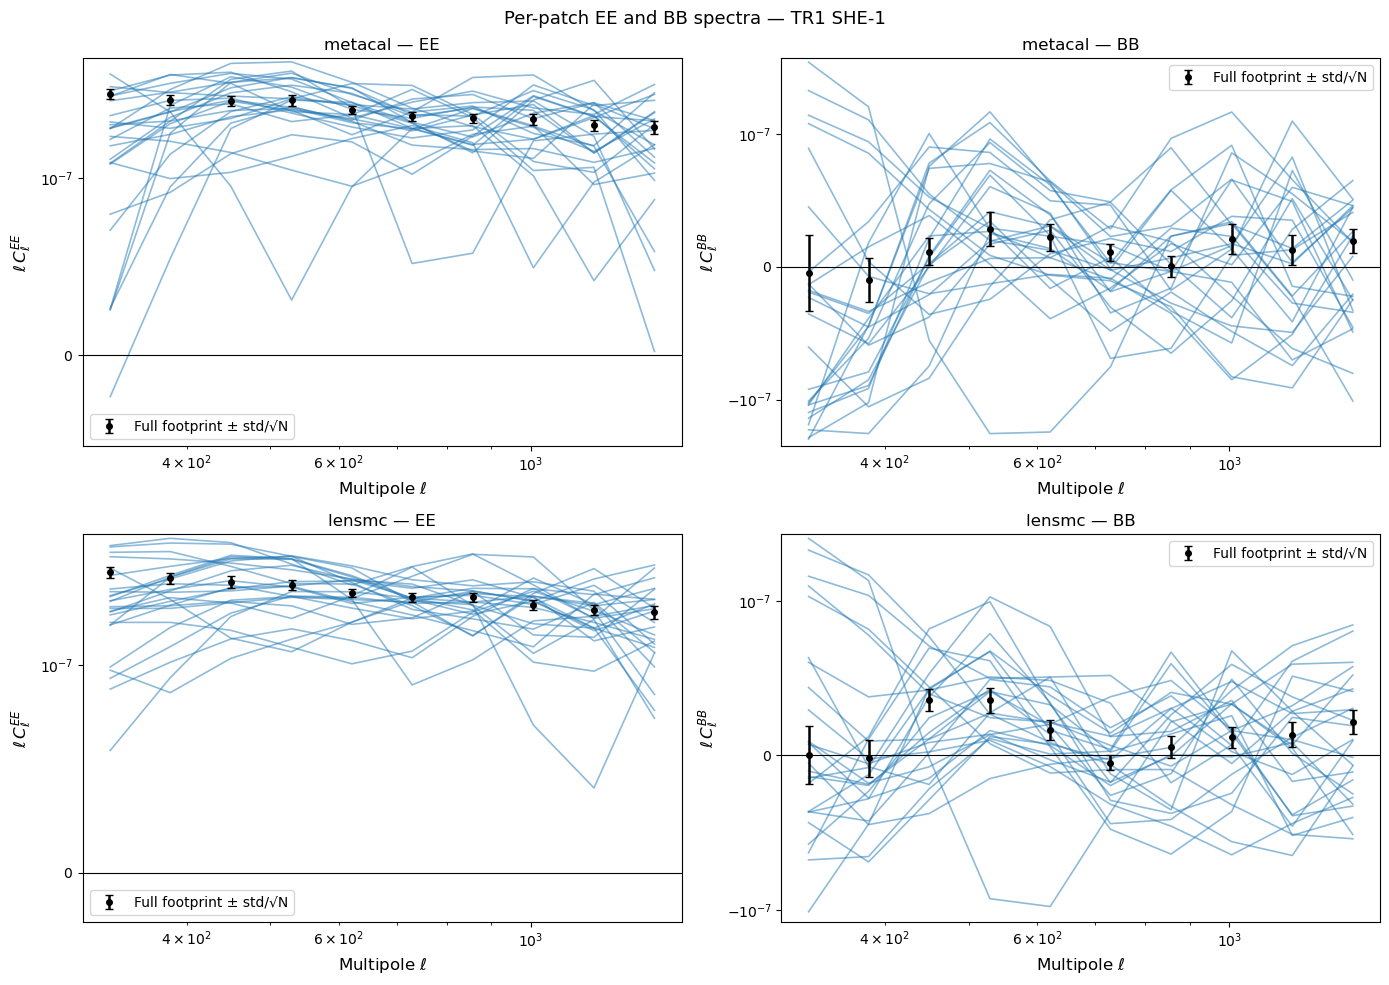

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)

for row, method in enumerate(methods):
    unmixed_binned = all_unmixed_binned[method]
    cl_full_data   = all_cl_full[method]

    for col, (component, comp_idx, err_key) in enumerate([
        ("EE", (0, 0), "err_ee"),
        ("BB", (1, 1), "err_bb"),
    ]):
        ax  = axes[row, col]
        err = cl_full_data[err_key]

        for label in range(1, n_patches + 1):
            key   = ("SHE", "SHE", label, label)
            cl_c  = unmixed_binned[key][comp_idx[0], comp_idx[1]]
            ell_b = unmixed_binned[key].ell
            ax.plot(ell_b, ell_b * cl_c, color="C0", lw=1.2, alpha=0.5)

        cl_full = cl_full_data[component.lower()]
        ax.errorbar(ell_full, ell_full * cl_full,
                    yerr=ell_full * err,
                    fmt="ko", ms=4, lw=1.8, capsize=3, zorder=10,
                    label="Full footprint ± std/√N")

        ax.axhline(0, color="k", lw=0.8)
        ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
        ax.set_ylabel(r"$\ell\,C_\ell^{" + component + r"}$", fontsize=12)
        ax.set_xscale("log")
        ax.set_title(f"{method} — {component}", fontsize=12)
        ax.set_yscale("symlog", linthresh=1e-7)
        ax.legend(fontsize=10)

plt.suptitle("Per-patch EE and BB spectra — TR1 SHE-1", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Leave-one-out $\chi^2$ outlier test

For each patch $k$ we compare its decoupled $C_\ell^{EE}$ to the mean of all
**other** patches:
$$\mu_{{-k}} = \frac{{1}}{{N-1}}\sum_{{j\neq k}} C_\ell^{{EE,j}}$$

The leave-one-out (LOO) $\chi^2$ is the Mahalanobis distance using the
covariance estimated from those same $N-1$ patches, so the outlier cannot
inflate its own reference or covariance.  Bins with $\ell < \ell_{{\min}}$
are excluded.

In [53]:
from scipy.stats import chi2 as chi2_dist

chi2_mask = ell_full >= lmin
p         = int(chi2_mask.sum())
N         = n_patches
print(f"Using {p} ell bins with ell >= {lmin}")

all_chi2_loo = {}

for method in methods:
    cls_chi2 = all_cl_full[method]["cls_patches_ee"][:, chi2_mask]

    chi2_loo = np.zeros(N)
    for k in range(N):
        idx_rest    = [j for j in range(N) if j != k]
        cls_rest    = cls_chi2[idx_rest]
        mu_loo      = cls_rest.mean(axis=0)
        cov_loo     = np.cov(cls_rest.T)
        diff        = cls_chi2[k] - mu_loo
        chi2_loo[k] = diff @ np.linalg.inv(cov_loo) @ diff

    all_chi2_loo[method] = chi2_loo

    print(f"{'Patch':>6}  {'chi2':>10}  {'chi2/p':>9}  [{method}]")
    print("-" * 38)
    for k in range(N):
        flag = "  <- OUTLIER" if chi2_loo[k]/p > 3 else ""
        print(f"  {k+1:3d}    {chi2_loo[k]:10.2f}   {chi2_loo[k]/p:7.2f}{flag}")
    print()


Using 10 ell bins with ell >= 300
 Patch        chi2     chi2/p  [metacal]
--------------------------------------
    1         12.60      1.26
    2         15.73      1.57
    3         39.46      3.95  <- OUTLIER
    4         10.40      1.04
    5         17.11      1.71
    6          9.06      0.91
    7         56.83      5.68  <- OUTLIER
    8          6.72      0.67
    9         14.42      1.44
   10          9.24      0.92
   11         11.66      1.17
   12         75.99      7.60  <- OUTLIER
   13         17.29      1.73
   14         16.45      1.64
   15         10.65      1.07
   16         31.74      3.17  <- OUTLIER
   17          8.97      0.90
   18         28.94      2.89
   19         17.16      1.72
   20         23.10      2.31
   21         11.17      1.12
   22         38.93      3.89  <- OUTLIER
   23          8.75      0.87
   24         28.61      2.86
   25          6.56      0.66

 Patch        chi2     chi2/p  [lensmc]
-----------------------------------

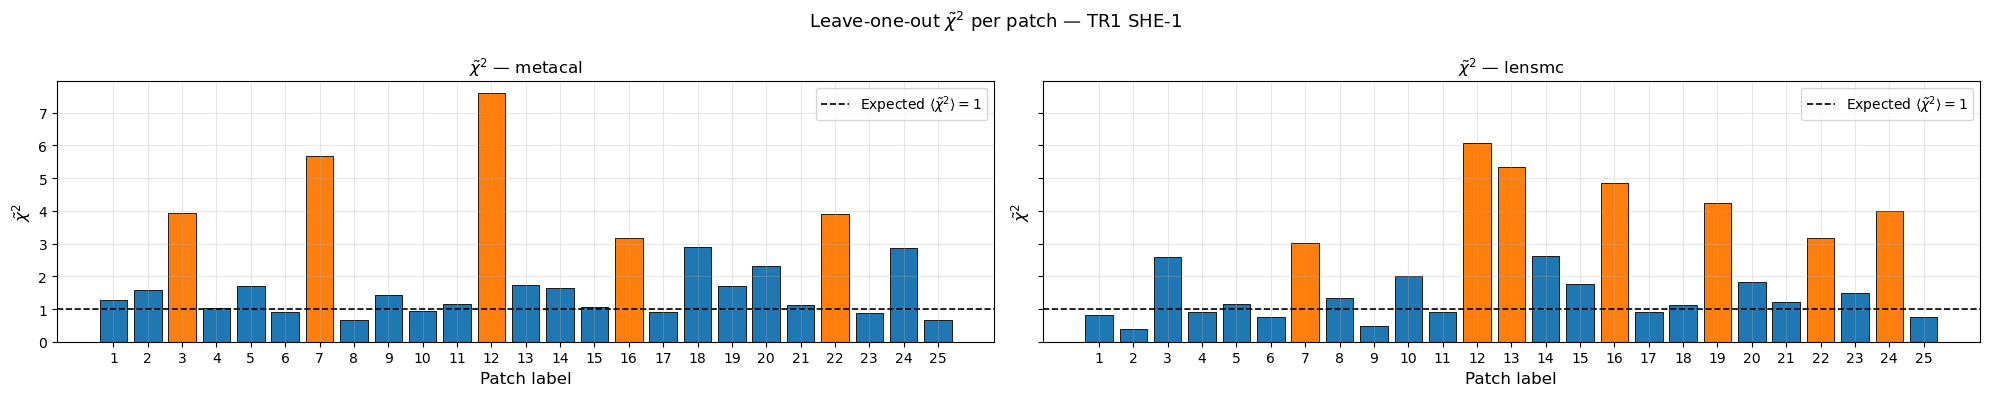

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(max(10, n_patches // 3) * 2, 4), sharey=True)

for ax, method in zip(axes, methods):
    chi2_loo = all_chi2_loo[method]
    colors   = ["C1" if chi2_loo[k]/p > 3 else "C0" for k in range(N)]
    ax.bar(range(1, N + 1), chi2_loo / nlbins, color=colors, edgecolor="k", linewidth=0.6)
    ax.axhline(1, color="k", ls="--", lw=1.2,
               label=rf"Expected $\langle \tilde{{\chi}}^2\rangle = 1$")
    ax.set_xlabel("Patch label", fontsize=12)
    ax.set_ylabel(r"$\tilde{\chi}^2$", fontsize=12)
    ax.set_xticks(range(1, N + 1))
    ax.set_title(rf"$\tilde{{\chi}}^2$ — {method}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(r"Leave-one-out $\tilde{\chi}^2$ per patch — TR1 SHE-1", fontsize=13)
plt.tight_layout()
plt.show()


/tmp/ipykernel_24653/1790278959.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon_c, lat_c  = float(lon_c), float(lat_c)


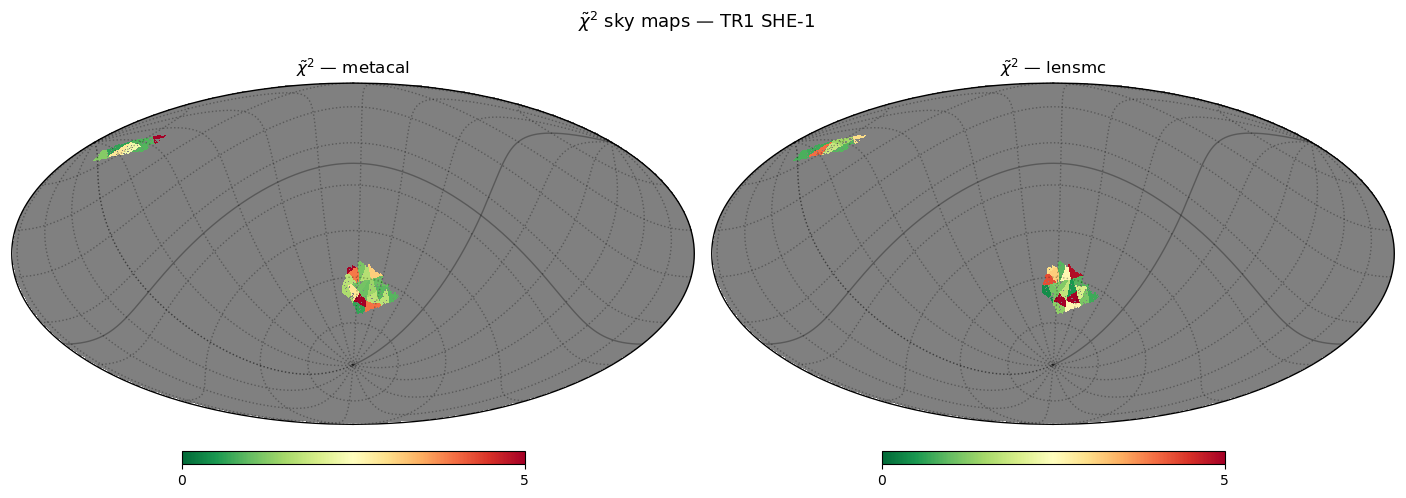

In [55]:
footprint_pix = np.where(jkmap > 0)[0]
vec           = np.mean(np.stack(hp.pix2vec(nside, footprint_pix), axis=1), axis=0)
lon_c, lat_c  = hp.vec2ang(vec / np.linalg.norm(vec), lonlat=True)
lon_c, lat_c  = float(lon_c), float(lat_c)

fig = plt.figure(figsize=(14, 5))

for col, method in enumerate(methods):
    sky_chi2 = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=np.float64)
    for k in range(N):
        sky_chi2[jkmap == k + 1] = all_chi2_loo[method][k] / nlbins

    hp.mollview(
        sky_chi2,
        fig=fig, sub=(1, 2, col + 1),
        rot=(lon_c, lat_c, 0),
        title=rf"$\tilde{{\chi}}^2$ — {method}",
        cmap="RdYlGn_r",
        min=0, max=5,
        notext=True,
    )

hp.graticule(dpar=5, dmer=5, alpha=0.3)
plt.suptitle(r"$\tilde{\chi}^2$ sky maps — TR1 SHE-1", fontsize=13)
plt.show()


<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24653/2117242862.py:40: SyntaxWarning: invalid escape sequence '\s'
  "\n(C1 = above 99% threshold, grey bands: $1\sigma$ / $2\sigma$)",


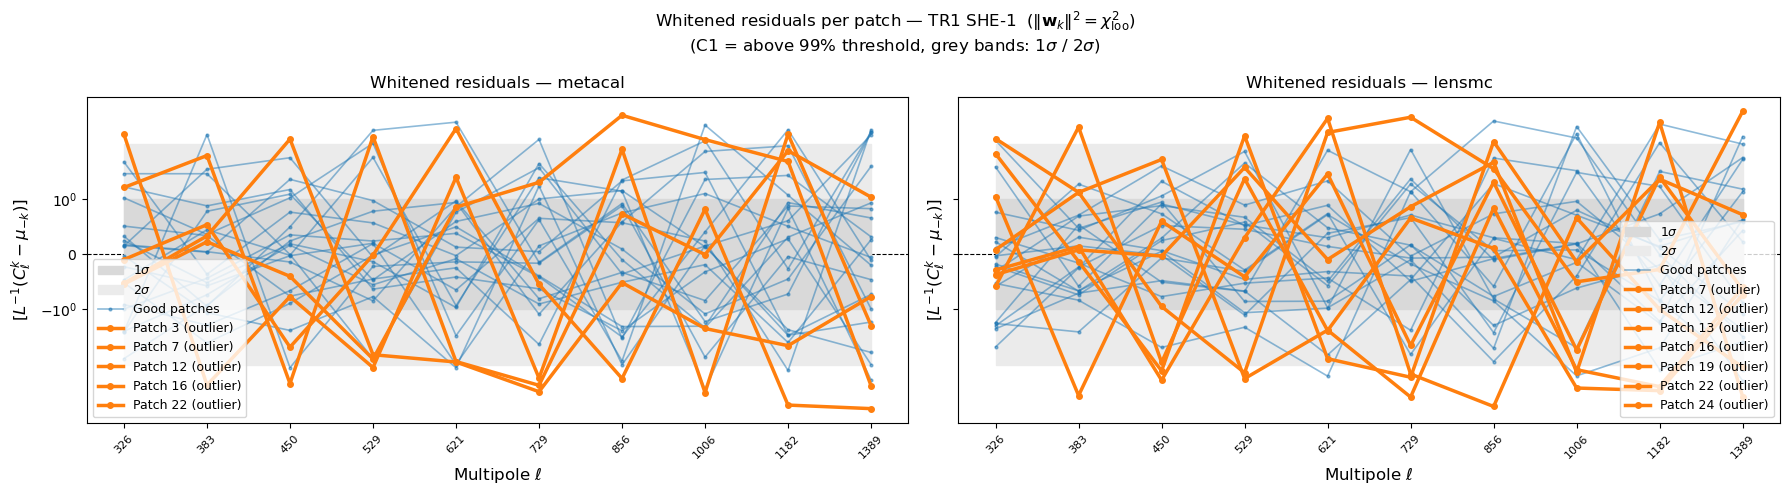

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, method in zip(axes, methods):
    cls_chi2 = all_cl_full[method]["cls_patches_ee"][:, chi2_mask]
    chi2_loo = all_chi2_loo[method]

    ax.axhline(0, color="k", lw=0.8, ls="--", zorder=0)
    ax.fill_between(range(p), -1, 1, color="0.85", zorder=1, label=r"$1\sigma$")
    ax.fill_between(range(p), -2, 2, color="0.92", zorder=0, label=r"$2\sigma$")

    for k in range(N):
        idx_rest = [j for j in range(N) if j != k]
        cls_rest = cls_chi2[idx_rest]
        mu_loo   = cls_rest.mean(axis=0)
        cov_loo  = np.cov(cls_rest.T)
        L        = np.linalg.cholesky(cov_loo)
        w        = np.linalg.solve(L, cls_chi2[k] - mu_loo)

        is_outlier = chi2_loo[k]/p > 3
        color  = "C1" if is_outlier else "C0"
        zorder = 5 if is_outlier else 2
        alpha  = 1.0 if is_outlier else 0.5
        lw     = 2.5 if is_outlier else 1.2
        label  = f"Patch {k+1} (outlier)" if is_outlier else ("Good patches" if k == 0 else None)
        ax.plot(range(p), w, color=color, lw=lw, alpha=alpha,
                marker="o", ms=4 if is_outlier else 2,
                zorder=zorder, label=label)

    ax.set_xticks(range(p))
    ax.set_xticklabels([f"{l:.0f}" for l in ell_full[chi2_mask]], rotation=45, fontsize=8)
    ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
    ax.set_ylabel(r"$[L^{-1}(C_\ell^k - \mu_{-k})]$", fontsize=12)
    ax.set_title(f"Whitened residuals — {method}", fontsize=12)
    ax.set_yscale("symlog", linthresh=2)
    ax.legend(fontsize=9)

plt.suptitle(
    r"Whitened residuals per patch — TR1 SHE-1"
    r"  ($\|\mathbf{w}_k\|^2 = \chi^2_\mathrm{loo}$)"
    "\n(C1 = above 99% threshold, grey bands: $1\sigma$ / $2\sigma$)",
    fontsize=12,
)
plt.tight_layout()
plt.show()


## 8. B-mode null test

We test the null hypothesis $H_0: C_\ell^{BB} = 0$ at two levels:

1. **Full footprint** — is the full-survey BB spectrum consistent with zero?  
   We use the sample covariance of the per-patch BBs divided by $N$ as the
   covariance of the full-footprint estimator, then form
   $\chi^2 = \mathbf{C}_\ell^{BB\,T}\,\mathrm{Cov}^{-1}\,\mathbf{C}_\ell^{BB}$
   and compare to $\chi^2(p)$.

2. **Per patch** — which individual patches show significant non-zero BB?  
   For each patch $k$ we use the leave-one-out covariance of the BB spectra
   from the remaining $N-1$ patches as the noise model and test
   $\mathbf{C}_\ell^{BB,k}$ against zero.

In [57]:
# ── 8a. Full-footprint BB significance ────────────────────────────────────
print(f"B-mode null test  (H₀: Cℓ^BB = 0,  {p} dof, \n")

all_chi2_bb_full  = {}
all_chi2_bb_patch = {}

for method in methods:
    cl_full_data   = all_cl_full[method]
    cls_patches_bb = cl_full_data["cls_patches_bb"][:, chi2_mask]

    # Full-footprint: sample cov / N_patches
    cov_bb_full  = np.cov(cls_patches_bb.T) / n_patches
    cl_bb_full   = cl_full_data["bb"][chi2_mask]
    chi2_bb_full = cl_bb_full @ np.linalg.inv(cov_bb_full) @ cl_bb_full
    all_chi2_bb_full[method] = {"chi2": chi2_bb_full}

    print(f"[{method}]  full-footprint  χ²/p = {chi2_bb_full/p:.3f}")

    # Per-patch: test Cℓ^BB_k against zero using LOO covariance from BB scatter
    chi2_bb_patch = np.zeros(N)
    for k in range(N):
        idx_rest         = [j for j in range(N) if j != k]
        cov_loo_bb       = np.cov(cls_patches_bb[idx_rest].T)
        chi2_bb_patch[k] = cls_patches_bb[k] @ np.linalg.inv(cov_loo_bb) @ cls_patches_bb[k]
    all_chi2_bb_patch[method] = chi2_bb_patch

    n_out = (chi2_bb_patch / p > 3).sum()
    print(f"[{method}]  per-patch outliers (BB > 3σ): {n_out}/{N}\n")


B-mode null test  (H₀: Cℓ^BB = 0,  10 dof, 

[metacal]  full-footprint  χ²/p = 11.104
[metacal]  per-patch outliers (BB > 3σ): 15/25

[lensmc]  full-footprint  χ²/p = 853.547
[lensmc]  per-patch outliers (BB > 3σ): 12/25



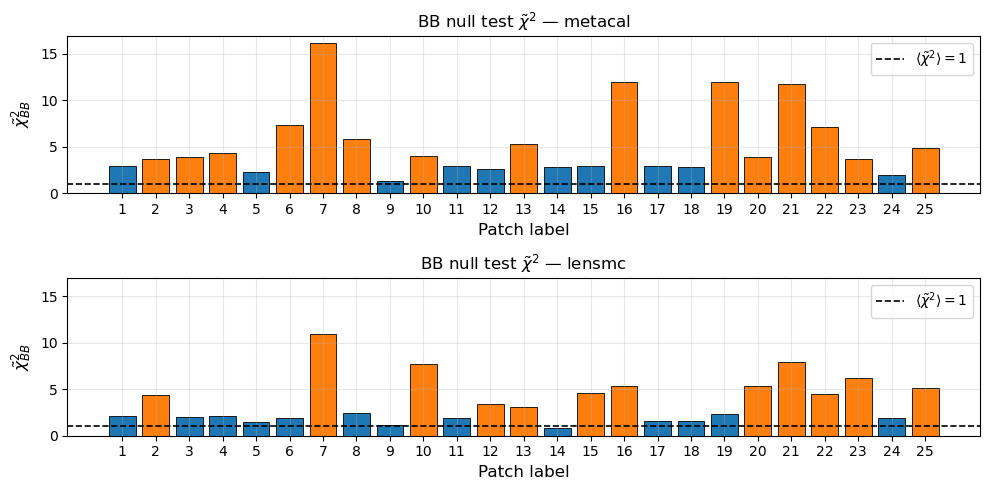

In [59]:
# ── 8c. Per-patch BB chi2 bar charts ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharey=True)

for ax, method in zip(axes, methods):
    chi2_bb = all_chi2_bb_patch[method]
    colors  = ["C1" if chi2_bb[k]/p > 3 else "C0" for k in range(N)]
    ax.bar(range(1, N + 1), chi2_bb / p, color=colors, edgecolor="k", linewidth=0.6)
    ax.axhline(1, color="k",  ls="--", lw=1.2, label=r"$\langle\tilde{\chi}^2\rangle = 1$")
    ax.set_xlabel("Patch label", fontsize=12)
    ax.set_ylabel(r"$\tilde{\chi}^2_{BB}$", fontsize=12)
    ax.set_xticks(range(1, N + 1))
    ax.set_title(rf"BB null test $\tilde{{\chi}}^2$ — {method}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

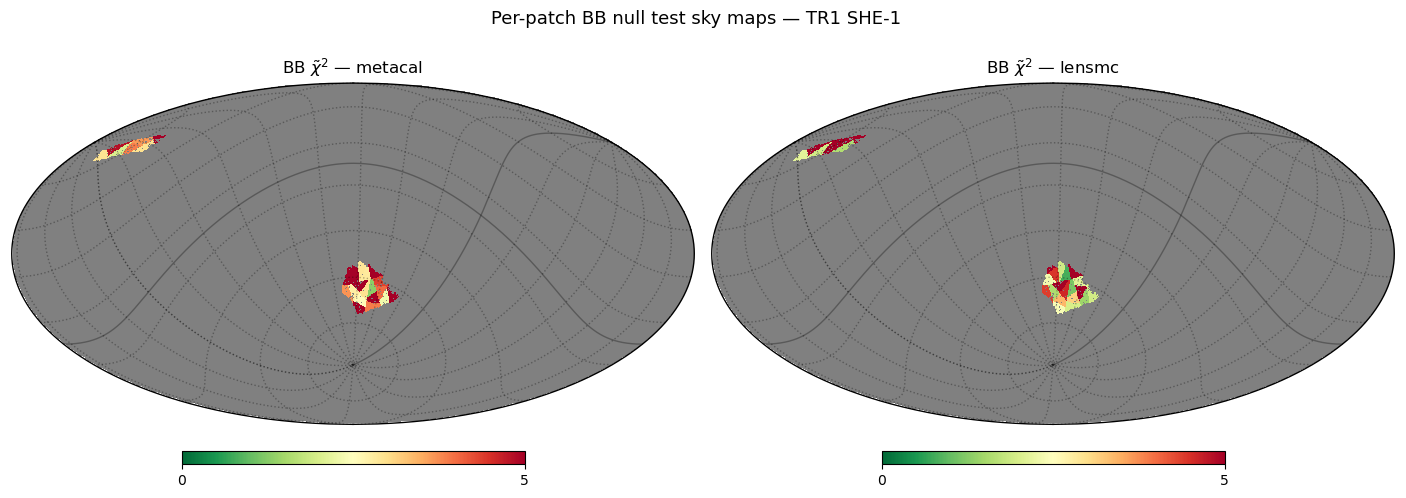

In [60]:
# ── 8d. Sky map of per-patch BB chi2 ──────────────────────────────────────
fig = plt.figure(figsize=(14, 5))

for col, method in enumerate(methods):
    sky_chi2_bb = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=np.float64)
    for k in range(N):
        sky_chi2_bb[jkmap == k + 1] = all_chi2_bb_patch[method][k] / p

    hp.mollview(
        sky_chi2_bb,
        fig=fig, sub=(1, 2, col + 1),
        rot=(lon_c, lat_c, 0),
        title=rf"BB $\tilde{{\chi}}^2$ — {method}",
        cmap="RdYlGn_r",
        min=0, max=5,
        notext=True,
    )

hp.graticule(dpar=5, dmer=5, alpha=0.3)
plt.suptitle(r"Per-patch BB null test sky maps — TR1 SHE-1", fontsize=13)
plt.show()

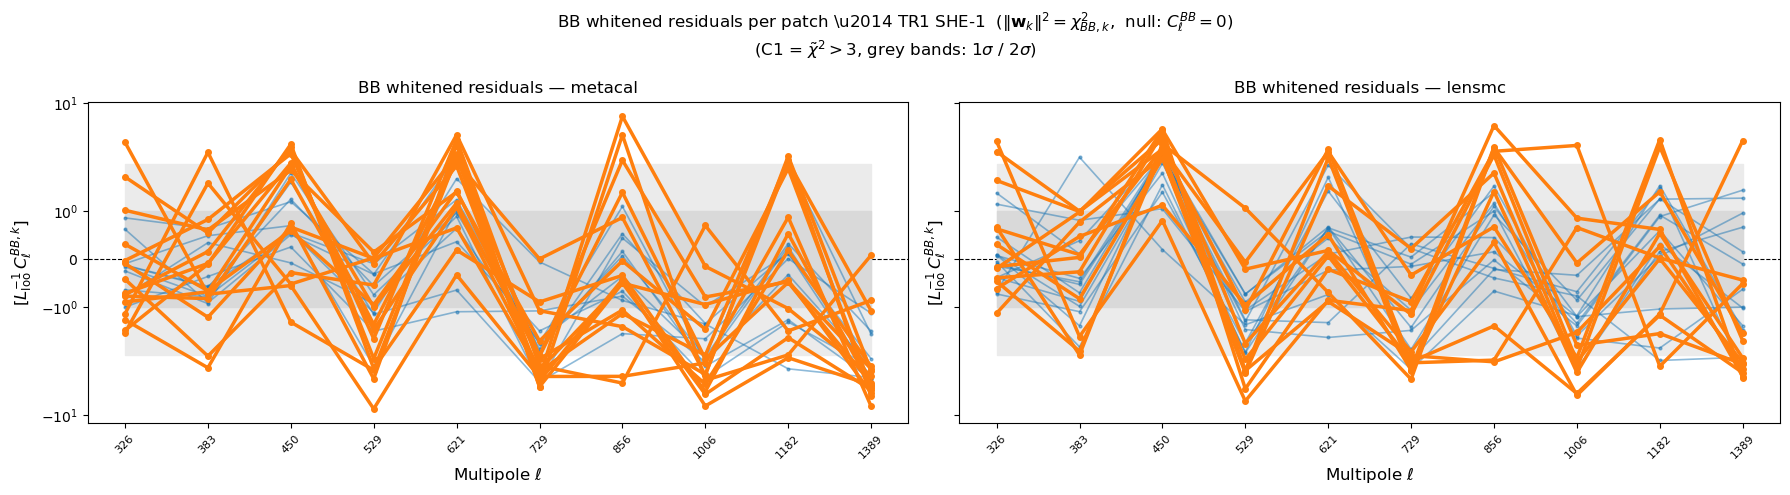

In [64]:
# ── 8e. BB whitened residuals ─────────────────────────────────────────────
# For BB the null is zero, so we whiten C_ell^BB_k itself (no LOO mean subtracted).
# w_k = L_loo^{-1} C_ell^BB_k,  ||w_k||^2 = chi2_bb_patch[k]

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, method in zip(axes, methods):
    cls_bb  = all_cl_full[method]["cls_patches_bb"][:, chi2_mask]
    chi2_bb = all_chi2_bb_patch[method]

    ax.axhline(0, color="k", lw=0.8, ls="--", zorder=0)
    ax.fill_between(range(p), -1, 1, color="0.85", zorder=1, label=r"$1\sigma$")
    ax.fill_between(range(p), -2, 2, color="0.92", zorder=0, label=r"$2\sigma$")

    for k in range(N):
        idx_rest = [j for j in range(N) if j != k]
        cov_loo  = np.cov(cls_bb[idx_rest].T)
        L        = np.linalg.cholesky(cov_loo)
        w        = np.linalg.solve(L, cls_bb[k])   # test against zero

        is_outlier = chi2_bb[k] / p > 3
        color  = "C1" if is_outlier else "C0"
        zorder = 5 if is_outlier else 2
        alpha  = 1.0 if is_outlier else 0.5
        lw     = 2.5 if is_outlier else 1.2
        label  = f"Patch {k+1} (BB detection)" if is_outlier else ("Null patches" if k == 0 else None)
        ax.plot(range(p), w, color=color, lw=lw, alpha=alpha,
                marker="o", ms=4 if is_outlier else 2,
                zorder=zorder, label=label)

    ax.set_xticks(range(p))
    ax.set_xticklabels([f"{l:.0f}" for l in ell_full[chi2_mask]], rotation=45, fontsize=8)
    ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
    ax.set_ylabel(r"$[L^{-1}_\mathrm{loo}\,C_\ell^{BB,k}]$", fontsize=12)
    ax.set_title(f"BB whitened residuals \u2014 {method}", fontsize=12)
    ax.set_yscale("symlog", linthresh=2)
    #ax.legend(fontsize=9)

plt.suptitle(
    r"BB whitened residuals per patch \u2014 TR1 SHE-1"
    r"  ($\|\mathbf{w}_k\|^2 = \chi^2_{BB,k}$,  null: $C_\ell^{BB}=0$)"
    "\n(C1 = $\\tilde{{\\chi}}^2 > 3$, grey bands: $1\\sigma$ / $2\\sigma$)",
    fontsize=12,
)
plt.tight_layout()
plt.show()


## 9. Cross-correlation of goodness-of-fit between metacal and lensmc

For each patch we compare $\tilde{\chi}^2_\mathrm{metacal}$ vs $\tilde{\chi}^2_\mathrm{lensmc}$.
A high Pearson correlation indicates that outlier patches are driven by sky systematics
common to both estimators; uncorrelated outliers point to estimator-specific effects.

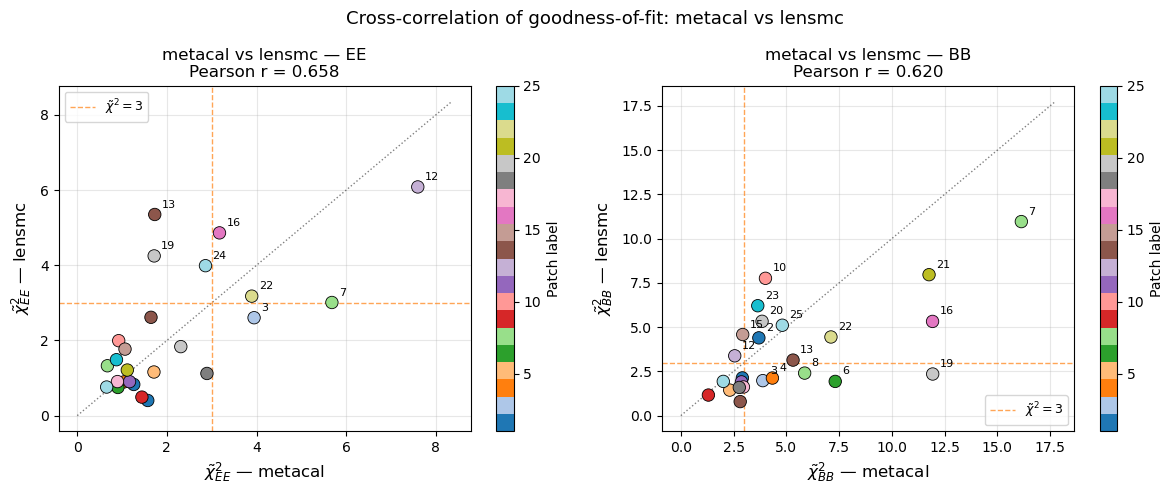

In [62]:
# EE: LOO chi2 (outlier vs mean of other patches)
chi2_ee_meta   = all_chi2_loo["metacal"] / p
chi2_ee_lensmc = all_chi2_loo["lensmc"]  / p
corr_ee        = np.corrcoef(chi2_ee_meta, chi2_ee_lensmc)[0, 1]

# BB: null test chi2 (detection of non-zero B-modes per patch)
chi2_bb_meta   = all_chi2_bb_patch["metacal"] / p
chi2_bb_lensmc = all_chi2_bb_patch["lensmc"]  / p
corr_bb        = np.corrcoef(chi2_bb_meta, chi2_bb_lensmc)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, x, y, corr) in zip(axes, [
    ("EE", chi2_ee_meta, chi2_ee_lensmc, corr_ee),
    ("BB", chi2_bb_meta, chi2_bb_lensmc, corr_bb),
]):
    sc = ax.scatter(x, y, c=range(1, N + 1), cmap="tab20",
                    s=80, edgecolors="k", linewidth=0.6, zorder=3)
    plt.colorbar(sc, ax=ax, label="Patch label")

    lim = max(x.max(), y.max()) * 1.1
    ax.plot([0, lim], [0, lim], "k:", lw=1, alpha=0.5)

    # Annotate patches that stand out in either method
    for k in range(N):
        if x[k] > 3 or y[k] > 3:
            ax.annotate(str(k + 1), (x[k], y[k]),
                        textcoords="offset points", xytext=(5, 5), fontsize=8)

    ax.axvline(3, color="C1", ls="--", lw=1, alpha=0.7)
    ax.axhline(3, color="C1", ls="--", lw=1, alpha=0.7, label=r"$\tilde{\chi}^2 = 3$")
    ax.set_xlabel(rf"$\tilde{{\chi}}^2_{{{label}}}$ — metacal", fontsize=12)
    ax.set_ylabel(rf"$\tilde{{\chi}}^2_{{{label}}}$ — lensmc", fontsize=12)
    ax.set_title(f"metacal vs lensmc — {label}\nPearson r = {corr:.3f}", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Cross-correlation of goodness-of-fit: metacal vs lensmc", fontsize=13)
plt.tight_layout()
plt.show()
